In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(r'C:\Users\ramal\Downloads\Stud Perf\student_performance.csv')

In [4]:
df.head()


,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [5]:
df.columns

Index(['student_id', 'gender', 'age', 'study_hours_per_week',
       'attendance_rate', 'parent_education', 'internet_access',
       'extracurricular', 'previous_score', 'final_score', 'passed'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    object 
 1   gender                500 non-null    object 
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    object 
 6   internet_access       500 non-null    object 
 7   extracurricular       500 non-null    object 
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 43.1+ KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

student_id                0
gender                    0
age                       0
study_hours_per_week      0
attendance_rate           0
parent_education        117
internet_access           0
extracurricular           0
previous_score            0
final_score               0
passed                    0
dtype: int64

In [10]:
df['parent_education'] = df['parent_education'].fillna(
    df['parent_education'].mode()[0]
)

In [11]:
df.isnull().sum()

student_id              0
gender                  0
age                     0
study_hours_per_week    0
attendance_rate         0
parent_education        0
internet_access         0
extracurricular         0
previous_score          0
final_score             0
passed                  0
dtype: int64

In [13]:
df.drop('student_id', axis=1, inplace=True)

In [14]:
df.head()

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,Female,19,10,90.5,High School,Yes,No,73,49,No
3,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,Female,15,25,73.0,High School,No,Yes,67,77,Yes


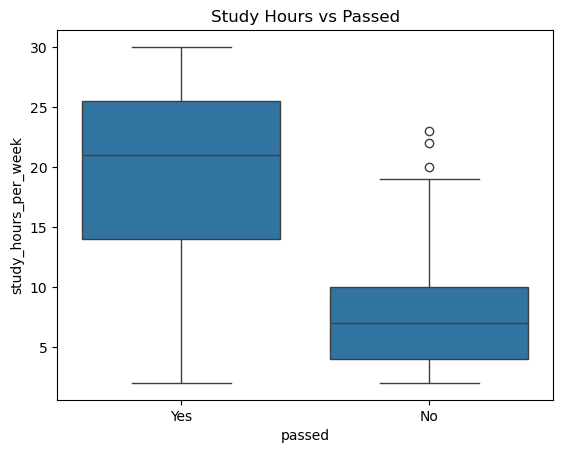

In [15]:
sns.boxplot(x='passed', y='study_hours_per_week', data=df)

plt.title('Study Hours vs Passed')
plt.show()

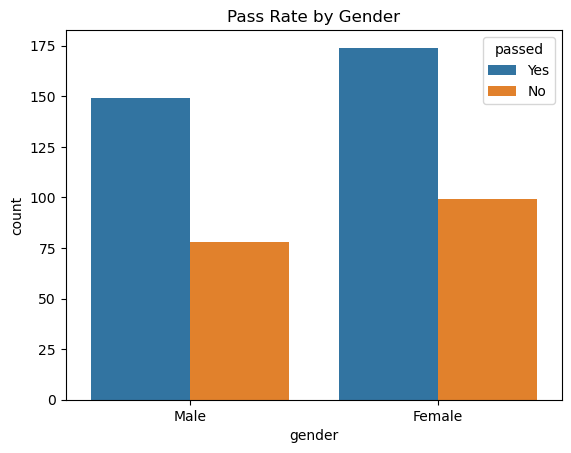

In [16]:
sns.countplot(x='gender', hue='passed', data=df)

plt.title('Pass Rate by Gender')
plt.show()

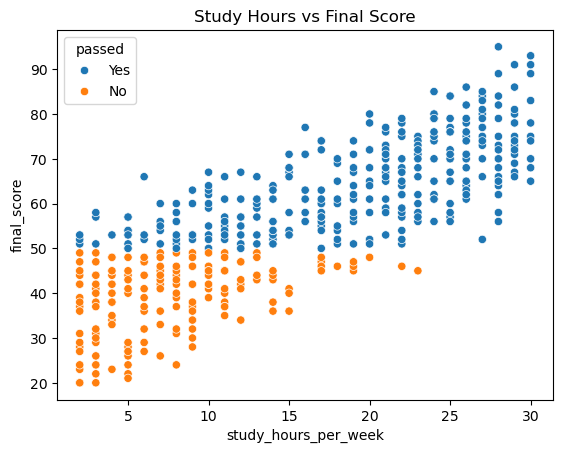

In [17]:
sns.scatterplot(x='study_hours_per_week',
                y='final_score',
                hue='passed',
                data=df)

plt.title('Study Hours vs Final Score')
plt.show()

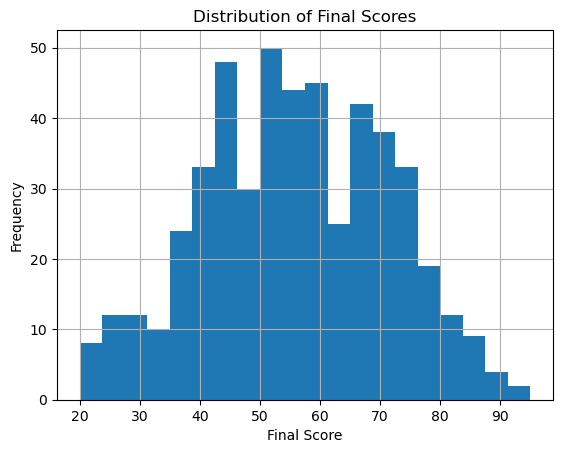

In [18]:
df['final_score'].hist(bins=20)

plt.title('Distribution of Final Scores')
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.show()

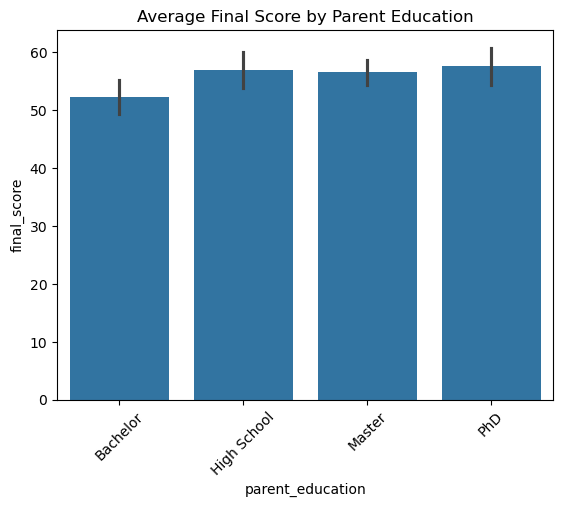

In [20]:
sns.barplot(x='parent_education',
            y='final_score',
            data=df)

plt.title('Average Final Score by Parent Education')
plt.xticks(rotation=45)
plt.show()

In [21]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

categorical_cols = ['gender', 'parent_education',
                    'internet_access', 'extracurricular',
                    'passed']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [23]:
df.head()

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,1,15,25,63.8,0,1,1,41,67,1
1,0,15,2,54.7,0,1,1,83,28,0
2,0,19,10,90.5,1,1,0,73,49,0
3,1,16,26,66.8,1,0,1,75,70,1
4,0,15,25,73.0,1,0,1,67,77,1


In [24]:
df.dtypes

gender                    int64
age                       int64
study_hours_per_week      int64
attendance_rate         float64
parent_education          int64
internet_access           int64
extracurricular           int64
previous_score            int64
final_score               int64
passed                    int64
dtype: object

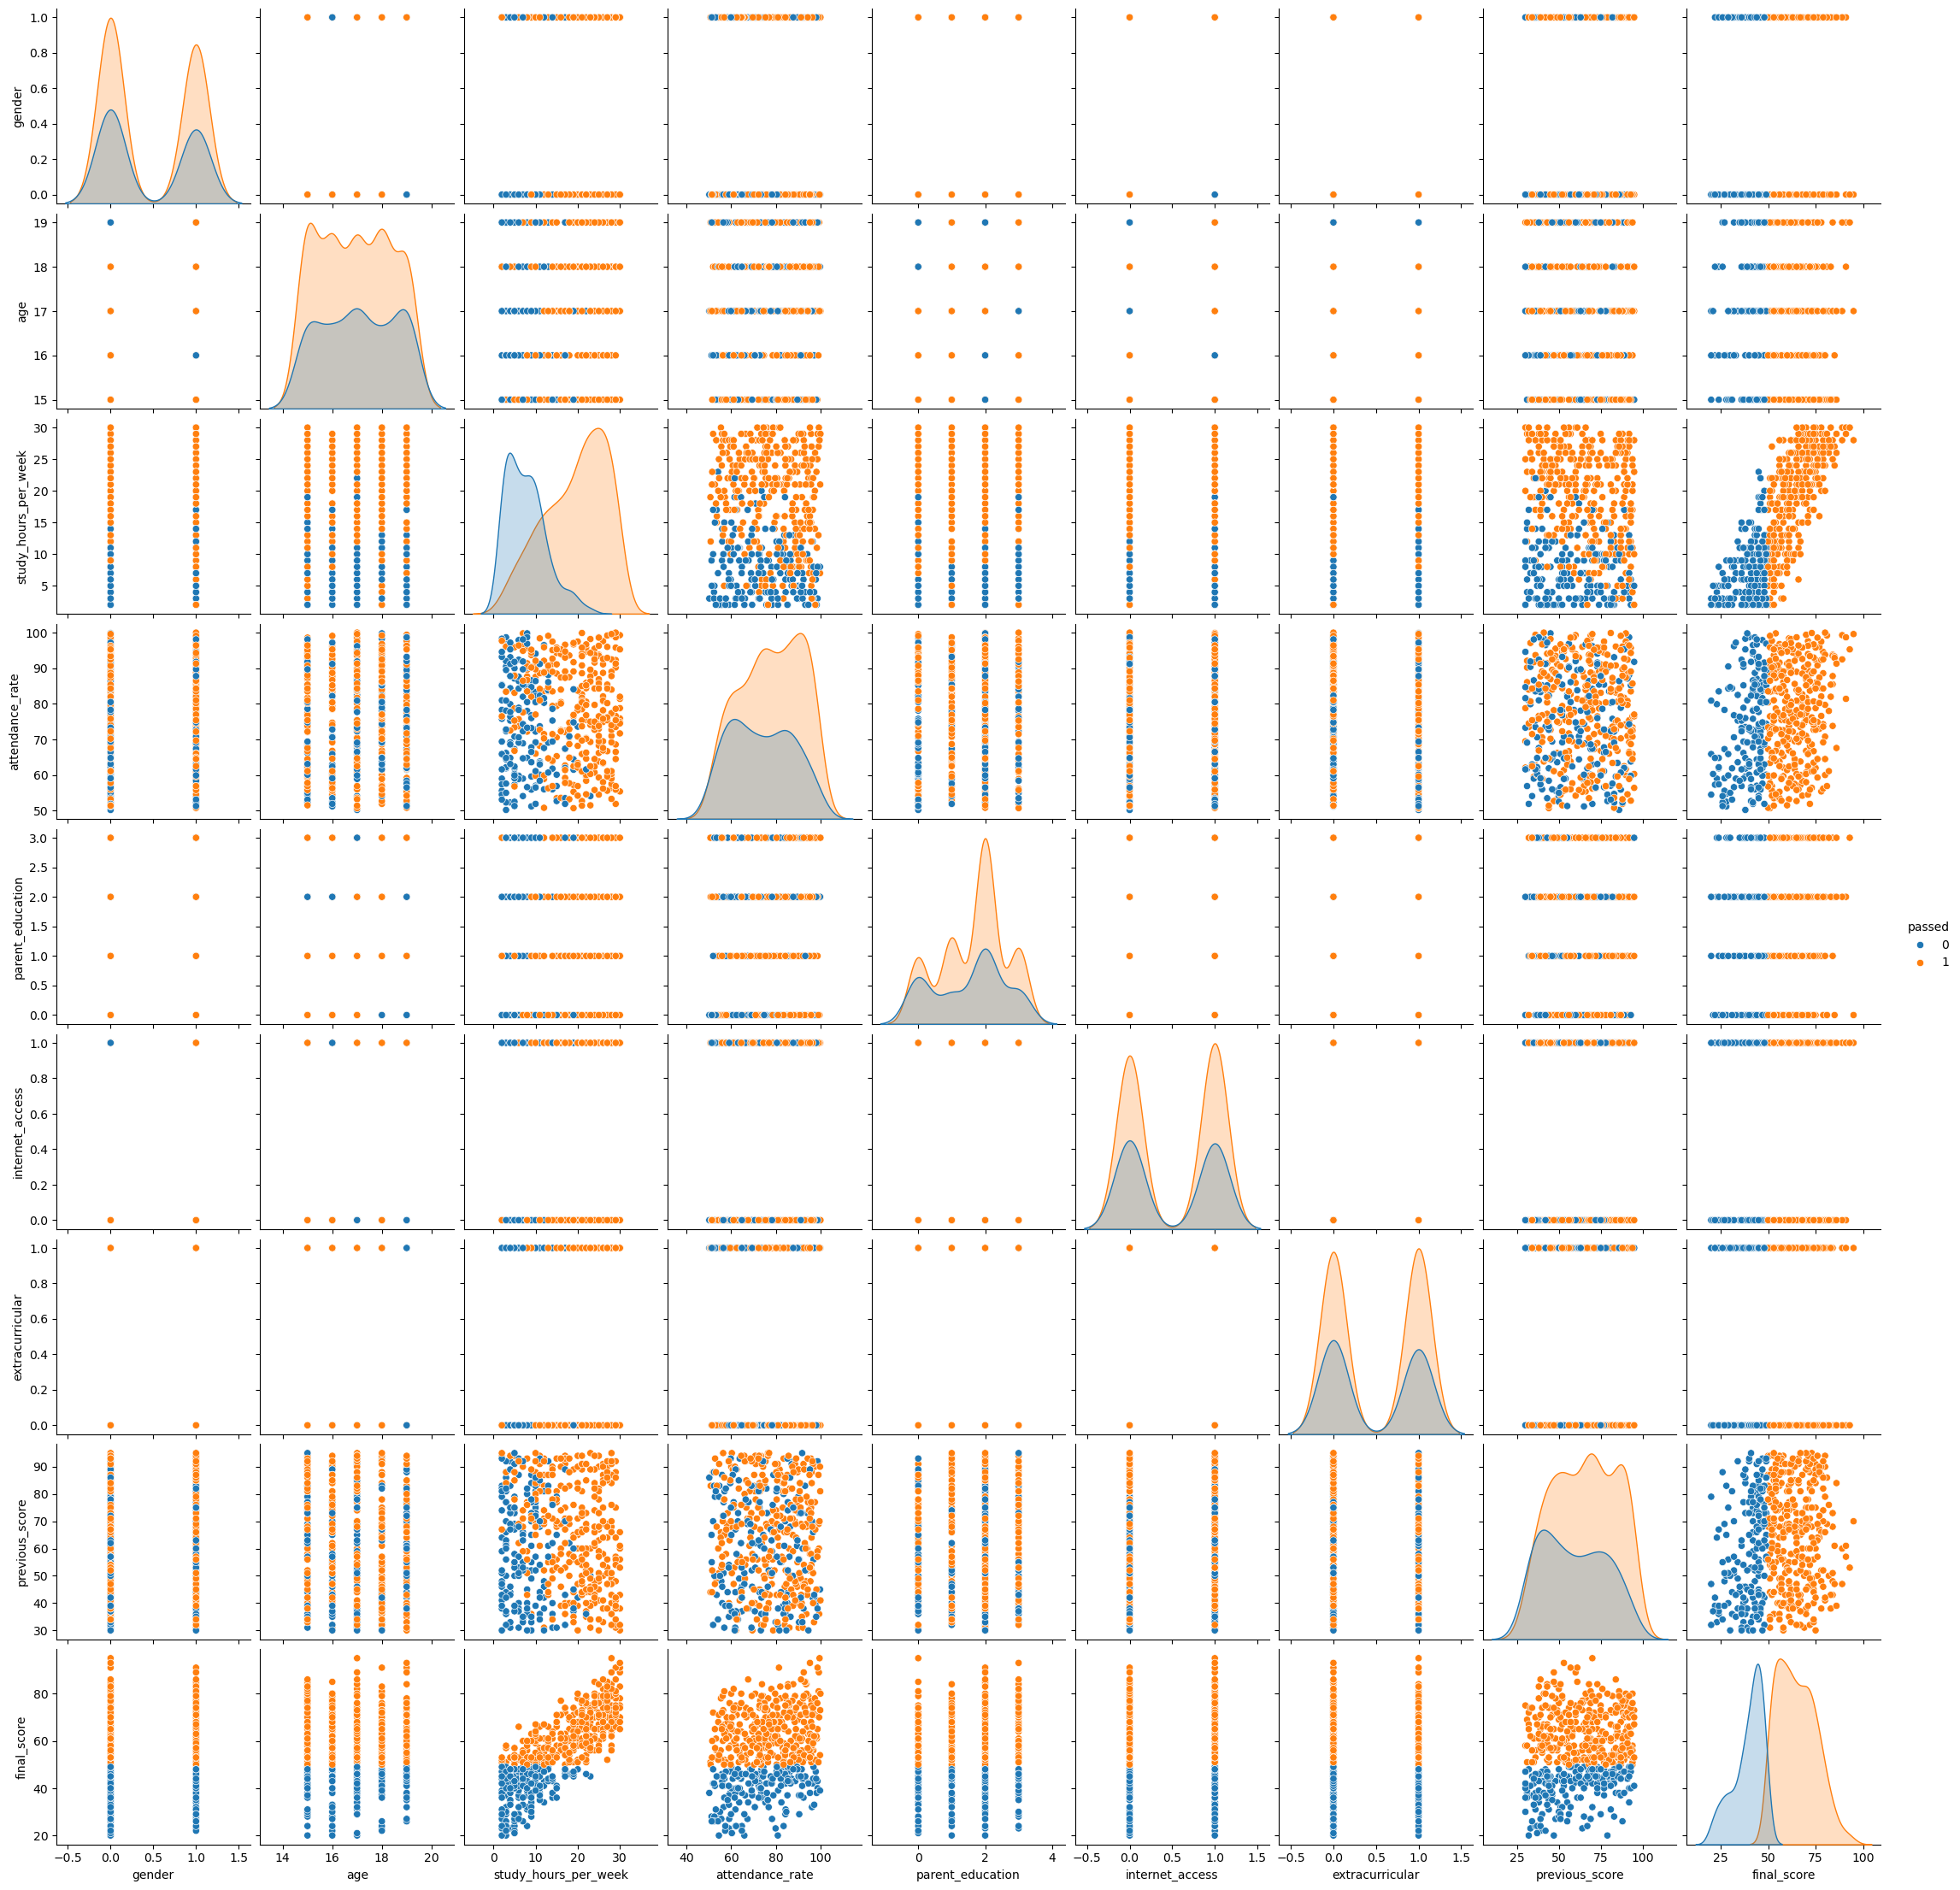

In [25]:
sns.pairplot(df, hue='passed')
plt.show()

In [26]:
df.groupby('gender')['final_score'].mean()

gender
0    55.542125
1    56.506608
Name: final_score, dtype: float64

In [27]:
df.groupby('parent_education')['final_score'].mean()

parent_education
0    52.175258
1    56.947368
2    56.589862
3    57.571429
Name: final_score, dtype: float64

In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,500.0,0.4540,0.498378,0.0,0.000,0.0,1.000,1.0
age,500.0,16.9780,1.434445,15.0,16.000,17.0,18.000,19.0
study_hours_per_week,500.0,15.3120,8.568167,2.0,8.000,15.0,23.000,30.0
attendance_rate,500.0,76.3806,13.817681,50.2,64.475,76.5,88.525,100.0
parent_education,500.0,1.6040,0.996579,0.0,1.000,2.0,2.000,3.0
internet_access,500.0,0.5080,0.500437,0.0,0.000,1.0,1.000,1.0
extracurricular,500.0,0.4940,0.500465,0.0,0.000,0.0,1.000,1.0
previous_score,500.0,62.9860,18.937451,30.0,46.000,64.0,79.000,95.0
final_score,500.0,55.9800,15.373754,20.0,45.000,56.0,68.000,95.0
passed,500.0,0.6460,0.478688,0.0,0.000,1.0,1.000,1.0


In [43]:
X = df.drop(['passed', 'final_score'], axis=1)
y = df['passed']

In [44]:
X

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score
0,1,15,25,63.8,0,1,1,41
1,0,15,2,54.7,0,1,1,83
2,0,19,10,90.5,1,1,0,73
3,1,16,26,66.8,1,0,1,75
4,0,15,25,73.0,1,0,1,67
...,...,...,...,...,...,...,...,...
495,0,19,6,78.3,2,0,0,51
496,0,16,27,61.1,3,0,0,47
497,0,18,16,72.3,2,0,1,52
498,1,17,29,91.3,2,1,0,39


In [45]:
y

0      1
1      0
2      0
3      1
4      1
      ..
495    0
496    1
497    1
498    1
499    1
Name: passed, Length: 500, dtype: int64

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC()
}

In [50]:
from sklearn.metrics import accuracy_score

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.8600
Decision Tree: 0.7400
Random Forest: 0.8400
KNN: 0.8400
SVM: 0.8600


In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[23 13]
 [ 1 63]]


In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.64      0.77        36
           1       0.83      0.98      0.90        64

    accuracy                           0.86       100
   macro avg       0.89      0.81      0.83       100
weighted avg       0.88      0.86      0.85       100



In [56]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=500,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=500)

In [58]:
y_pred = model.predict(X_test_scaled)
y_pred

array([1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1])

In [59]:
from sklearn.metrics import accuracy_score, classification_report

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.88
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        36
           1       0.91      0.91      0.91        64

    accuracy                           0.88       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.88      0.88      0.88       100



In [60]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print(scores)
print(scores.mean())

[0.85 0.85 0.81 0.77 0.86]
0.828


In [61]:
import joblib

joblib.dump(model, 'student_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']